<a href="https://colab.research.google.com/github/FatiBuuloloo/SaliencyMap-Modeling_Human_Visual_Attention_for_Ad_Creative_Optimization-mini_project-014/blob/main/SALIENCY_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import os
import cv2
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import requests
from PIL import Image
import io
import matplotlib.pyplot as plt

# Collecting Data

In [ ]:
drive.mount('/content/drive')
images_path = '/content/drive/MyDrive/SALICON/images'
maps_path = '/content/drive/MyDrive/SALICON/maps'

In [ ]:
seed = 42
batch_size=16
images_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)
maps_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)

train_images_generator = images_datagen.flow_from_directory(images_path, target_size=(224, 224), batch_size=batch_size, class_mode=None, seed=seed)
train_maps_generator = maps_datagen.flow_from_directory(maps_path, target_size=(224, 224), batch_size=batch_size, class_mode=None, color_mode='grayscale', seed=seed)

def combine_generator(gen1, gen2):
    while True:
        yield (next(gen1), next(gen2))

Found 10000 images belonging to 1 classes.
Found 10000 images belonging to 1 classes.


In [ ]:
train_generator = combine_generator(train_images_generator, train_maps_generator)

# Model

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
outputs = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 56, 56, 128)    │             

 Total params: 18,641,729 (71.11 MB)

 Trainable params: 3,927,041 (14.98 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Training Model (Phase 1)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/SALICON/last_best_epoch.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,save_best_only=True,
    monitor='loss',mode='min',verbose=1)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-5), loss='mse', metrics=['mae'])
steps_per_epoch = train_images_generator.samples // train_images_generator.batch_size
history = model.fit(train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, callbacks=[checkpoint_callback])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - loss: 0.0384 - mae: 0.1362 
Epoch 1: loss improved from None to 0.02312, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 8552s 14s/step - loss: 0.0231 - mae: 0.0966
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - loss: 0.0150 - mae: 0.0722 
Epoch 2: loss improved from 0.02312 to 0.01460, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 8495s 14s/step - loss: 0.0146 - mae: 0.0710
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0140 - mae: 0.0688 
Epoch 3: loss improved from 0.01460 to 0.01388, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 3: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.ke

# Training Model (Phase 2)

In [ ]:
drive.mount('/content/drive')
checkpoint_path = "/content/drive/MyDrive/SALICON/last_best_epoch.keras"
model = tf.keras.models.load_model(checkpoint_path)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,save_best_only=True,
    monitor='loss',mode='min',verbose=1)

Mounted at /content/drive


In [ ]:
images_path = '/content/drive/MyDrive/SALICON/images'
maps_path = '/content/drive/MyDrive/SALICON/maps'

seed = 42
batch_size=16
images_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)
maps_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)

train_images_generator = images_datagen.flow_from_directory(images_path, target_size=(224, 224), batch_size=batch_size, class_mode=None, seed=seed)
train_maps_generator = maps_datagen.flow_from_directory(maps_path, target_size=(224, 224), batch_size=batch_size, class_mode=None, color_mode='grayscale', seed=seed)

def combine_generator(gen1, gen2):
    while True:
        yield (next(gen1), next(gen2))

train_generator = combine_generator(train_images_generator, train_maps_generator)
steps_per_epoch = train_images_generator.samples // train_images_generator.batch_size

Found 10000 images belonging to 1 classes.
Found 10000 images belonging to 1 classes.


In [ ]:
history = model.fit(train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, initial_epoch=4,
    callbacks=[checkpoint_callback])

Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - loss: 0.0131 - mae: 0.0656 
Epoch 5: loss improved from None to 0.01308, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 5: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 9629s 15s/step - loss: 0.0131 - mae: 0.0657
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - loss: 0.0130 - mae: 0.0652 
Epoch 6: loss improved from 0.01308 to 0.01286, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 6: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 9422s 15s/step - loss: 0.0129 - mae: 0.0650
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - loss: 0.0128 - mae: 0.0646 
Epoch 7: loss improved from 0.01286 to 0.01269, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 7: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.ke

# Training Model (Phase 3)

In [ ]:
drive.mount('/content/drive')
checkpoint_path = "/content/drive/MyDrive/SALICON/last_best_epoch.keras"
model = tf.keras.models.load_model(checkpoint_path)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,save_best_only=True,
    monitor='loss',mode='min',verbose=1)

Mounted at /content/drive


In [ ]:
images_path = '/content/drive/MyDrive/SALICON/images'
maps_path = '/content/drive/MyDrive/SALICON/maps'

seed = 42
batch_size=16
images_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)
maps_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)

train_images_generator = images_datagen.flow_from_directory(images_path, target_size=(224, 224), batch_size=batch_size, class_mode=None, seed=seed)
train_maps_generator = maps_datagen.flow_from_directory(maps_path, target_size=(224, 224), batch_size=batch_size, class_mode=None, color_mode='grayscale', seed=seed)

def combine_generator(gen1, gen2):
    while True:
      yield (next(gen1), next(gen2))

train_generator = combine_generator(train_images_generator, train_maps_generator)
steps_per_epoch = train_images_generator.samples // train_images_generator.batch_size

Found 10000 images belonging to 1 classes.
Found 10000 images belonging to 1 classes.


In [ ]:
history = model.fit(train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, initial_epoch=8,
    callbacks=[checkpoint_callback])

Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0122 - mae: 0.0628 
Epoch 9: loss improved from None to 0.01225, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 9: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 8427s 13s/step - loss: 0.0123 - mae: 0.0630
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0122 - mae: 0.0628 
Epoch 10: loss improved from 0.01225 to 0.01211, saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras

Epoch 10: finished saving model to /content/drive/MyDrive/SALICON/last_best_epoch.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 8241s 13s/step - loss: 0.0121 - mae: 0.0626


In [ ]:
import os
save_dir = '/content/drive/MyDrive/SALICON/'
os.makedirs(save_dir, exist_ok=True)

keras_path = os.path.join(save_dir, 'model_final_saliency.keras')
h5_path = os.path.join(save_dir, 'model_final_saliency.h5')

model.save(keras_path)
model.save(h5_path)

# Evaluation

In [ ]:
drive.mount('/content/drive')
model_path = "/content/drive/MyDrive/SALICON/model_final_saliency.keras"
images_dir = "/content/drive/MyDrive/images_val"
maps_dir   = "/content/drive/MyDrive/maps_val"

images_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
maps_files = sorted([f for f in os.listdir(maps_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

print(f"Total Images : {len(images_files)}")
print(f"Total Maps : {len(maps_files)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total Images : 5000
Total Maps : 5000


In [ ]:
set_images = {os.path.splitext(f)[0] for f in images_files}
set_maps = {os.path.splitext(f)[0] for f in maps_files}

missing_in_maps = set_images - set_maps
missing_in_images = set_maps - set_images

In [ ]:
if len(missing_in_maps) > 0:
    for name in list(missing_in_maps):
        print(f"   - {name}")
else:
    print("All images have corresponding maps.")

if len(missing_in_images) > 0:
    for name in list(missing_in_images):
        print(f"   - {name}")
else:
    print("All maps have corresponding images")

All images have corresponding maps.
All maps have corresponding images


In [ ]:
model = tf.keras.models.load_model(model_path)
input_height = model.input_shape[1]
input_width  = model.input_shape[2]

In [ ]:
def calculate_kl_divergence(y_true, y_pred):
    y_true = y_true.flatten().astype(np.float32)
    y_pred = y_pred.flatten().astype(np.float32)
    eps = 1e-10
    y_true = y_true / (np.sum(y_true) + eps)
    y_pred = y_pred / (np.sum(y_pred) + eps)
    kl_div = np.sum(y_true * np.log((y_true + eps) / (y_pred + eps)))
    return kl_div

def calculate_auc_judd(y_true, y_pred):
    y_true_norm = y_true.flatten().astype(np.float32) / 255.0
    y_pred_flat = y_pred.flatten().astype(np.float32)
    threshold = np.mean(y_true_norm)
    y_true_binary = (y_true_norm > threshold).astype(int)
    if len(np.unique(y_true_binary)) == 1:
        return np.nan
    return roc_auc_score(y_true_binary, y_pred_flat)

In [ ]:
kl_scores = []
auc_scores = []
for i in tqdm(range(len(images_files)), desc="Model Evaluation"):
    img_path = os.path.join(images_dir, images_files[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (input_width, input_height))
    img_input = img_resized.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_input, axis=0)
    map_path = os.path.join(maps_dir, maps_files[i])
    gt_map = cv2.imread(map_path, cv2.IMREAD_GRAYSCALE)
    gt_map_resized = cv2.resize(gt_map, (input_width, input_height))
    pred_map = model.predict(img_input, verbose=0)
    pred_map = np.squeeze(pred_map)
    pred_map = (pred_map - np.min(pred_map)) / (np.max(pred_map) - np.min(pred_map) + 1e-10)
    kl = calculate_kl_divergence(gt_map_resized, pred_map)
    auc = calculate_auc_judd(gt_map_resized, pred_map)

    kl_scores.append(kl)
    if not np.isnan(auc):
        auc_scores.append(auc)
mean_kl = np.mean(kl_scores)
mean_auc = np.mean(auc_scores)

print(f"KL Divergence : {mean_kl:.4f}")
print(f"AUC-Judd      : {mean_auc:.4f} ")

Model Evaluation: 100%|██████████| 5000/5000 [1:49:16<00:00,  1.31s/it]

KL Divergence : 0.3912
AUC-Judd      : 0.9332 


# Testing

In [ ]:
def load_image_from_github(url):
    raw_url = url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")
    response = requests.get(raw_url)
    img = Image.open(io.BytesIO(response.content)).convert('RGB')
    return img

def show_original_ads(url):
    img = load_image_from_github(url)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title("Original Ad")
    plt.axis('off')
    plt.show()
    return img

def predict_and_show_heatmap(img_pil, model):
    img_array = np.array(img_pil)
    h_model, w_model = model.input_shape[1:3]
    img_resized = cv2.resize(img_array, (w_model, h_model))
    img_input = img_resized.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_input, axis=0)
    prediction = model.predict(img_input, verbose=0)
    heatmap = np.squeeze(prediction)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-10)
    original_w, original_h = img_pil.size
    heatmap_resized = cv2.resize(heatmap, (original_w, original_h))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_array, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(12, 8))
    plt.imshow(overlay)
    plt.title("Visual Attention Overlay")
    plt.axis('off')

    plt.show()

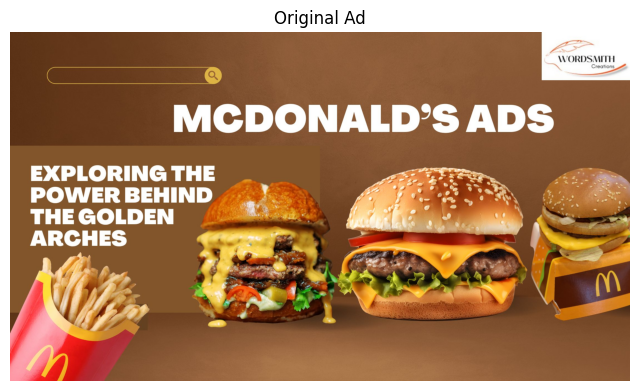

In [ ]:
github_url = "https://github.com/FatiBuuloloo/SaliencyMap-Modeling_Human_Visual_Attention_for_Ad_Creative_Optimization-mini_project-014/blob/main/ads_sample/ads_1.jpg"
img_original = show_original_ads(github_url)

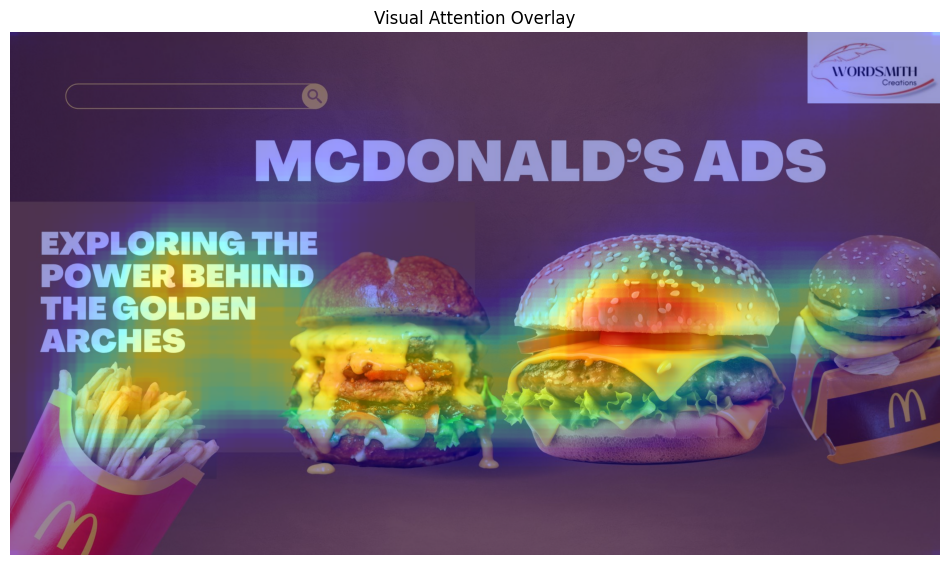

In [ ]:
predict_and_show_heatmap(img_original, model)

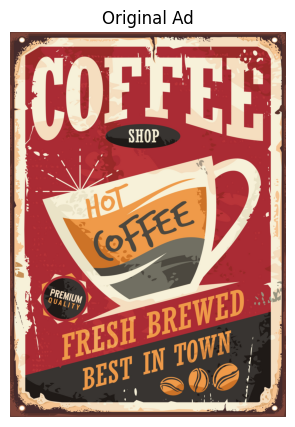

In [ ]:
github_url1 = "https://github.com/FatiBuuloloo/SaliencyMap-Modeling_Human_Visual_Attention_for_Ad_Creative_Optimization-mini_project-014/blob/main/ads_sample/ads_2.jpg"
img_original1 = show_original_ads(github_url1)

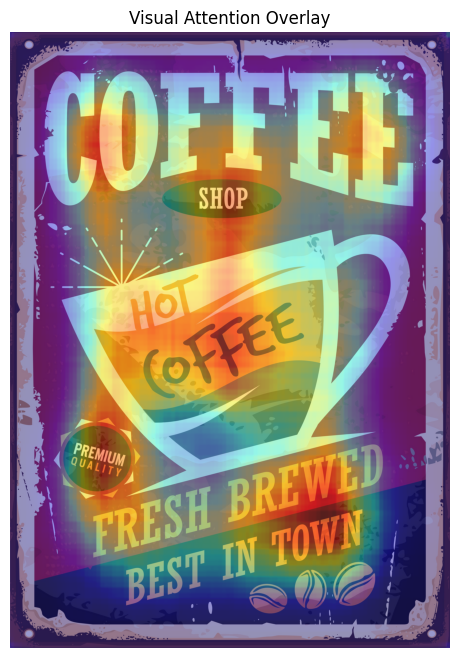

In [ ]:
predict_and_show_heatmap(img_original1, model)

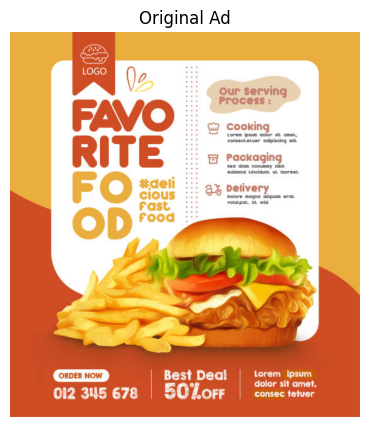

In [ ]:
github_url2 = "https://github.com/FatiBuuloloo/SaliencyMap-Modeling_Human_Visual_Attention_for_Ad_Creative_Optimization-mini_project-014/blob/main/ads_sample/ads_3.jpg"
img_original2 = show_original_ads(github_url2)

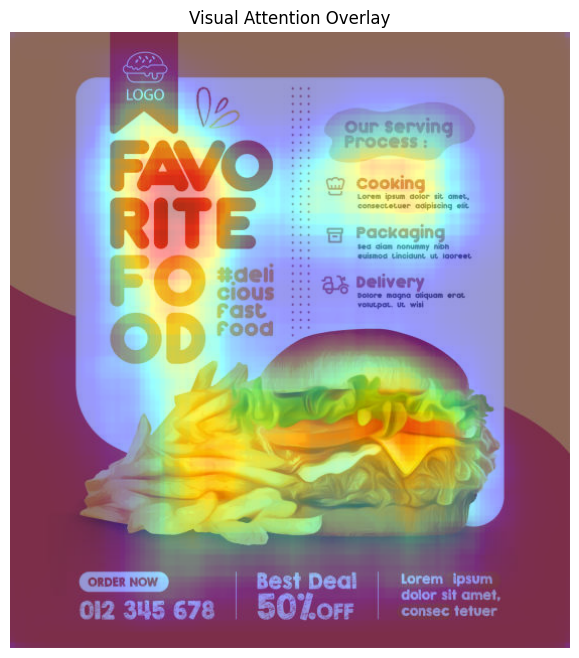

In [ ]:
predict_and_show_heatmap(img_original2, model)

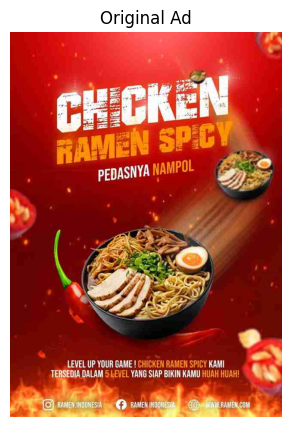

In [ ]:
github_url3 = "https://github.com/FatiBuuloloo/SaliencyMap-Modeling_Human_Visual_Attention_for_Ad_Creative_Optimization-mini_project-014/blob/main/ads_sample/ads_4.jpg"
img_original3 = show_original_ads(github_url3)

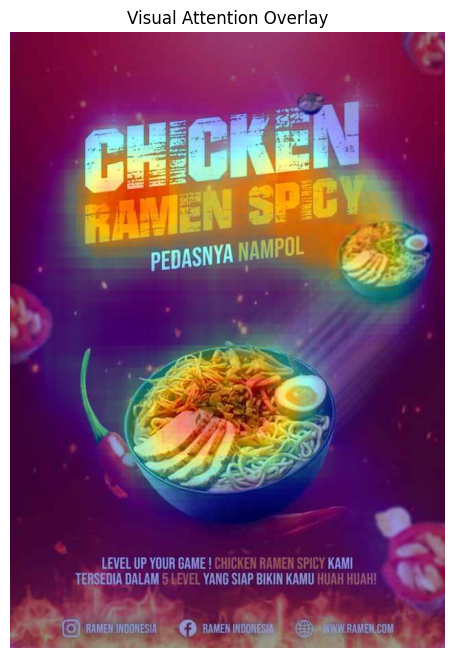

In [ ]:
predict_and_show_heatmap(img_original3, model)

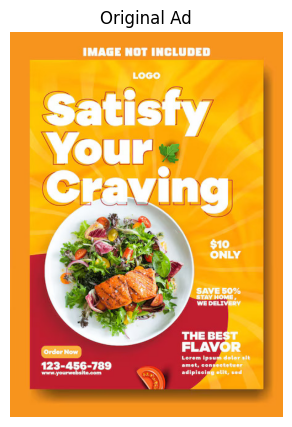

In [ ]:
github_url4 = "https://github.com/FatiBuuloloo/SaliencyMap-Modeling_Human_Visual_Attention_for_Ad_Creative_Optimization-mini_project-014/blob/main/ads_sample/ads_5.jpg"
img_original4 = show_original_ads(github_url4)

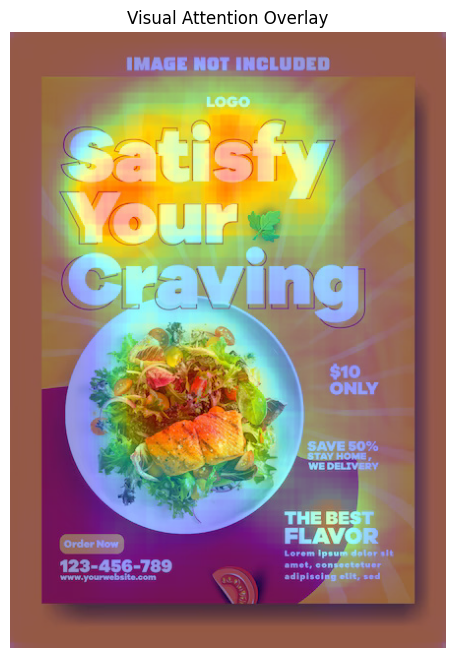

In [ ]:
predict_and_show_heatmap(img_original4, model)